# Master's Thesis Notebook

This notebook is part of the **Master's Thesis (MSc Dissertation)**: **Fast Simulation of Neutrino Oscillations in Matter**.

**Author**  
Juan Ramon Diaz Santos <diazjuan@alumni.uv.es>

**Supervisors**  
Roberto Ruiz de Austri Bazan <rruiz@ific.uv.es>  
Michele Lucente <michele.lucente@unibo.it>

**Date**  
June 2026


# test0 potential

Notebook equivalent of `tests/1_core/test0_potential.py`. The original Python test module remains the source of truth; this notebook imports it and runs each `test_*` function in its own cell for interactive inspection.

The notebook uses the shared TPeanuts output-root convention defined in section `2. Paths`. Generated test artifacts and figures are redirected to the notebook-specific `OUTPUT_DIR` under `OUTPUT_TEST_ROOT / "core" / NOTEBOOK_STEM`.


## 1. Libraries and test module

This section locates the repository, imports the original Python test module, and reloads it so changes in the source file are reflected when the notebook is rerun. The expected result is that the module imports without errors. Possible problems include running the notebook from outside the repository tree or missing editable installation paths.


In [1]:
from __future__ import annotations

import importlib
import importlib.util
import os
import sys
import traceback
from pathlib import Path

import matplotlib.pyplot as plt


from tpeanuts.util.notebooks import find_repo_root
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

NOTEBOOK_STEM = "test0_potential"
TEST_MODULE_PATH = PACKAGE_DIR / "notebooks" / "tests" / "1_core" / f"{NOTEBOOK_STEM}.py"
TEST_MODULE_NAME = f"notebook_tests_{TEST_MODULE_PATH.parent.name.replace('.', '_')}_{NOTEBOOK_STEM}"
if not TEST_MODULE_PATH.exists():
    raise FileNotFoundError(f"Could not find local test module: {TEST_MODULE_PATH}")
spec = importlib.util.spec_from_file_location(TEST_MODULE_NAME, TEST_MODULE_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load test module spec from {TEST_MODULE_PATH}")
TEST_MODULE = importlib.util.module_from_spec(spec)
sys.modules[TEST_MODULE_NAME] = TEST_MODULE
spec.loader.exec_module(TEST_MODULE)
print("Loaded local test module:", TEST_MODULE_PATH)

from tpeanuts.util.notebooks import build_notebook_test_runner


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Loaded local test module: G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\notebooks\tests\1_core\test0_potential.py


## 2. Paths

All outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. This notebook writes test figures and any generated artifacts under `OUTPUT_TEST_ROOT / "core" / NOTEBOOK_STEM`, while data, analysis, benchmark, and external roots are defined with the same shared structure used by the analysis notebooks.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_TEST_ROOT / "core" / NOTEBOOK_STEM
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_PLOTS = True
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\test\core\test0_potential


In [3]:
NOTEBOOK_RUNNER_ATTRS = {}
if "RUN_REAL_DATA_ANALYSIS" in globals():
    NOTEBOOK_RUNNER_ATTRS["RUN_REAL_mceq_run1_analysis"] = RUN_REAL_DATA_ANALYSIS

runner = build_notebook_test_runner(
    TEST_MODULE,
    OUTPUT_DIR,
    show_plots=SHOW_PLOTS,
    auto_save_figures=True,
    extra_module_attrs=NOTEBOOK_RUNNER_ATTRS,
)
run_notebook_test = runner.run_test
run_notebook_call = runner.run_call


## Test: `test_matter_potential_formula`

**What is checked:** Matter potential formula behavior and numerical consistency.
- V = matter_potential(n, antinu=False)

**Expected result:** The expected result is a clean pass for these checks: 
- V = R_E * 3.868e-7 * n.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [4]:
run_notebook_test(TEST_MODULE.test_matter_potential_formula)


Running test_matter_potential_formula ...

------------------------------------------------------------------------------------------
TEST: matter_potential formula
------------------------------------------------------------------------------------------
n [mol/cm^3]:
tensor([0.0000000000e+00, 1.0000000000e+00, 2.0000000000e+00, 5.0000000000e+00], device='cuda:0', dtype=torch.float64)
V neutrino:
tensor([0.0000000000e+00, 2.4643028000e+00, 4.9286056000e+00, 1.2321514000e+01], device='cuda:0', dtype=torch.float64)
V expected:
tensor([0.0000000000e+00, 2.4643028000e+00, 4.9286056000e+00, 1.2321514000e+01], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_matter_potential_formula


## Test: `test_matter_potential_antinu_sign`

**What is checked:** Matter potential antinu sign behavior and numerical consistency.
- V_nu = matter_potential(n, antinu=False)
- V_anti = matter_potential(n, antinu=True)

**Expected result:** The expected result is a clean pass for these checks: 
- Antineutrino matter potential is -V_neutrino.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [5]:
run_notebook_test(TEST_MODULE.test_matter_potential_antinu_sign)


Running test_matter_potential_antinu_sign ...

------------------------------------------------------------------------------------------
TEST: matter_potential antineutrino sign
------------------------------------------------------------------------------------------
V neutrino:
tensor([0.0000000000e+00, 2.4643028000e+00, 4.9286056000e+00, 7.3929084000e+00, 9.8572112000e+00, 1.2321514000e+01, 1.4785816800e+01, 1.7250119600e+01, 1.9714422400e+01, 2.2178725200e+01,
        2.4643028000e+01], device='cuda:0', dtype=torch.float64)
V antineutrino:
tensor([-0.0000000000e+00, -2.4643028000e+00, -4.9286056000e+00, -7.3929084000e+00, -9.8572112000e+00, -1.2321514000e+01, -1.4785816800e+01, -1.7250119600e+01, -1.9714422400e+01,
        -2.2178725200e+01, -2.4643028000e+01], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_matter_potential_antinu_sign


## Test: `test_matter_potential_shape_dtype_device`

**What is checked:** Matter potential shape dtype device behavior and numerical consistency.
- V = matter_potential(n, antinu=False)

**Expected result:** The expected result is a clean pass for these checks: assert_true.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; shape, dtype, or broadcasting changes may break downstream vectorized calls.


In [6]:
run_notebook_test(TEST_MODULE.test_matter_potential_shape_dtype_device)


Running test_matter_potential_shape_dtype_device ...

------------------------------------------------------------------------------------------
TEST: matter_potential shape, dtype and device
------------------------------------------------------------------------------------------
n shape: torch.Size([4, 5])
V shape: torch.Size([4, 5])
n dtype: torch.float64
V dtype: torch.float64
device: cuda:0
------------------------------------------------------------------------------------------
PASSED: test_matter_potential_shape_dtype_device


## Test: `test_kinetic_potential_scalar_energy`

**What is checked:** Kinetic potential scalar energy behavior and numerical consistency.
- k = kinetic_potential(mSq, E)

**Expected result:** The expected result is a clean pass for these checks: assert_true; kinetic_potential scalar energy formula.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [7]:
run_notebook_test(TEST_MODULE.test_kinetic_potential_scalar_energy)


Running test_kinetic_potential_scalar_energy ...

------------------------------------------------------------------------------------------
TEST: kinetic_potential with scalar energy
------------------------------------------------------------------------------------------
mSq [eV^2]:
tensor([0.0000000000e+00, 7.4200000000e-05, 2.5170000000e-03], device='cuda:0', dtype=torch.float64)
E [MeV]:
tensor(1.0000000000e+03, device='cuda:0', dtype=torch.float64)
k:
tensor([0.0000000000e+00, 1.1978296101e+00, 4.0632575858e+01], device='cuda:0', dtype=torch.float64)
k expected:
tensor([0.0000000000e+00, 1.1978296101e+00, 4.0632575858e+01], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_kinetic_potential_scalar_energy


## Test: `test_kinetic_potential_energy_grid`

**What is checked:** Kinetic potential energy grid behavior and numerical consistency.
- E = torch.logspace(2.0, 5.0, 8, dtype=DTYPE, device=DEVICE)
- k = kinetic_potential(mSq, E)

**Expected result:** The expected result is a clean pass for these checks: assert_true; kinetic_potential energy-grid broadcasting.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [8]:
run_notebook_test(TEST_MODULE.test_kinetic_potential_energy_grid)


Running test_kinetic_potential_energy_grid ...

------------------------------------------------------------------------------------------
TEST: kinetic_potential with energy grid
------------------------------------------------------------------------------------------
E grid [MeV]:
tensor([ 1.0000000000e+02,  2.6826957953e+02,  7.1968567300e+02,  1.9306977289e+03,  5.1794746792e+03,  1.3894954944e+04,  3.7275937203e+04,  1.0000000000e+05],
       device='cuda:0', dtype=torch.float64)
k shape: torch.Size([8, 3])
k:
tensor([[0.0000000000e+00, 1.1978296101e+01, 4.0632575858e+02],
        [0.0000000000e+00, 4.4650221327e+00, 1.5146173461e+02],
        [0.0000000000e+00, 1.6643788463e+00, 5.6458781080e+01],
        [0.0000000000e+00, 6.2041281357e-01, 2.1045539781e+01],
        [0.0000000000e+00, 2.3126469079e-01, 7.8449221928e+00],
        [0.0000000000e+00, 8.6206080910e-02, 2.9242682702e+00],
        [0.0000000000e+00, 3.2134124585e-02, 1.0900484041e+00],
        [0.0000000000e+00, 1.1

## Test: `test_kinetic_potential_batched_mass_and_energy`

**What is checked:** Kinetic potential batched mass and energy behavior and numerical consistency.
- E = torch.logspace(2.0, 5.0, 8, dtype=DTYPE, device=DEVICE)
- mSq = torch.tensor(
        [
            [0.0, 7.42e-5, 2.517e-3],
            [0.0, 7.42e-5, 2.517e-3],
            [0.0, 7.42e-5, 2.517e-3],
        ],
        dtype=DTYPE,
        device=DEVICE,
    )
- k = kinetic_potential(mSq, E)

**Expected result:** The expected result is a clean pass for these checks: assert_true; kinetic_potential batched formula.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change; shape, dtype, or broadcasting changes may break downstream vectorized calls.


In [9]:
run_notebook_test(TEST_MODULE.test_kinetic_potential_batched_mass_and_energy)


Running test_kinetic_potential_batched_mass_and_energy ...

------------------------------------------------------------------------------------------
TEST: kinetic_potential with batched mSq and E
------------------------------------------------------------------------------------------
mSq shape: torch.Size([3, 3])
E shape: torch.Size([3])
k shape: torch.Size([3, 3])
k:
tensor([[0.0000000000e+00, 2.3956592203e+00, 8.1265151717e+01],
        [0.0000000000e+00, 1.1978296101e+00, 4.0632575858e+01],
        [0.0000000000e+00, 2.3956592203e-01, 8.1265151717e+00]], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_kinetic_potential_batched_mass_and_energy


## Test: `test_kinetic_potential_inverse_energy_scaling`

**What is checked:** Kinetic potential inverse energy scaling behavior and numerical consistency.
- k1 = kinetic_potential(mSq, E1)
- k2 = kinetic_potential(mSq, E2)
- ratio = k1[1:] / k2[1:]

**Expected result:** The expected result is a clean pass for these checks: k scales as 1/E.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [10]:
run_notebook_test(TEST_MODULE.test_kinetic_potential_inverse_energy_scaling)


Running test_kinetic_potential_inverse_energy_scaling ...

------------------------------------------------------------------------------------------
TEST: kinetic_potential inverse-energy scaling
------------------------------------------------------------------------------------------
k(E=1000 MeV):
tensor([0.0000000000e+00, 1.1978296101e+00, 4.0632575858e+01], device='cuda:0', dtype=torch.float64)
k(E=2000 MeV):
tensor([0.0000000000e+00, 5.9891480506e-01, 2.0316287929e+01], device='cuda:0', dtype=torch.float64)
ratio k(E1)/k(E2):
tensor([2.0000000000e+00, 2.0000000000e+00], device='cuda:0', dtype=torch.float64)
------------------------------------------------------------------------------------------
PASSED: test_kinetic_potential_inverse_energy_scaling


## Test: `test_kinetic_potential_requires_tensors`

**What is checked:** Kinetic potential requires tensors behavior and numerical consistency.

**Expected result:** The expected result is that the cell completes without raising an exception.

**Possible problems:** a failed assertion usually indicates a numerical regression or an unexpected API change.


In [11]:
run_notebook_test(TEST_MODULE.test_kinetic_potential_requires_tensors)


Running test_kinetic_potential_requires_tensors ...

------------------------------------------------------------------------------------------
TEST: kinetic_potential requires torch tensors
------------------------------------------------------------------------------------------
[OK]     TypeError raised when mSq_eV2 is not a torch.Tensor
[OK]     TypeError raised when E_MeV is not a torch.Tensor
------------------------------------------------------------------------------------------
PASSED: test_kinetic_potential_requires_tensors


## Diagnostic plots outside pytest tests

The original Python file also defines standalone diagnostic plot functions. They are not pytest `test_*` functions, but they are part of the interactive test script behavior. Each plot block below redirects generated images to the shared notebook `OUTPUT_DIR` and displays them only when `SHOW_PLOTS = True`.


### Plot: `plot_matter_potential_vs_density`

**What is checked:** this diagnostic visualizes the numerical relationship exercised by the potential tests and makes trend regressions easy to inspect by eye.

**Expected result:** the function writes the following image file(s) to `OUTPUT_DIR` and displays the plot inline when `SHOW_PLOTS = True`:

- `matter_potential_vs_density.png`

**Possible problems:** a missing file can indicate a path or permission problem; a blank, discontinuous, or non-finite curve can indicate a numerical regression or a changed tensor/device configuration.


Running plot_matter_potential_vs_density ...

------------------------------------------------------------------------------------------
PLOT: matter potential vs density
------------------------------------------------------------------------------------------
Saved plot: V:\output\test\core\test0_potential\plot_matter_potential_vs_density_figure_001.png
------------------------------------------------------------------------------------------
PASSED: plot_matter_potential_vs_density


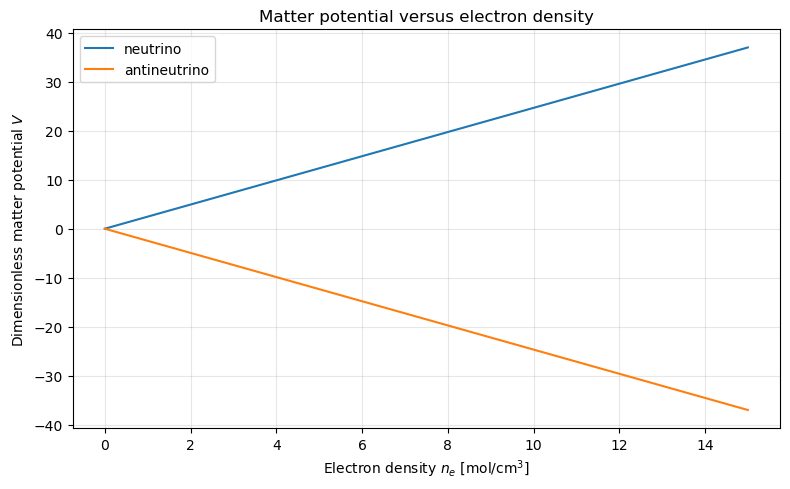

In [12]:

run_notebook_test(TEST_MODULE.plot_matter_potential_vs_density)


### Plot: `plot_kinetic_potential_vs_energy`

**What is checked:** this diagnostic visualizes the numerical relationship exercised by the potential tests and makes trend regressions easy to inspect by eye.

**Expected result:** the function writes the following image file(s) to `OUTPUT_DIR` and displays the plot inline when `SHOW_PLOTS = True`:

- `kinetic_potential_vs_energy.png`

**Possible problems:** a missing file can indicate a path or permission problem; a blank, discontinuous, or non-finite curve can indicate a numerical regression or a changed tensor/device configuration.


Running plot_kinetic_potential_vs_energy ...

------------------------------------------------------------------------------------------
PLOT: kinetic potential vs energy
------------------------------------------------------------------------------------------
Saved plot: V:\output\test\core\test0_potential\plot_kinetic_potential_vs_energy_figure_001.png
------------------------------------------------------------------------------------------
PASSED: plot_kinetic_potential_vs_energy


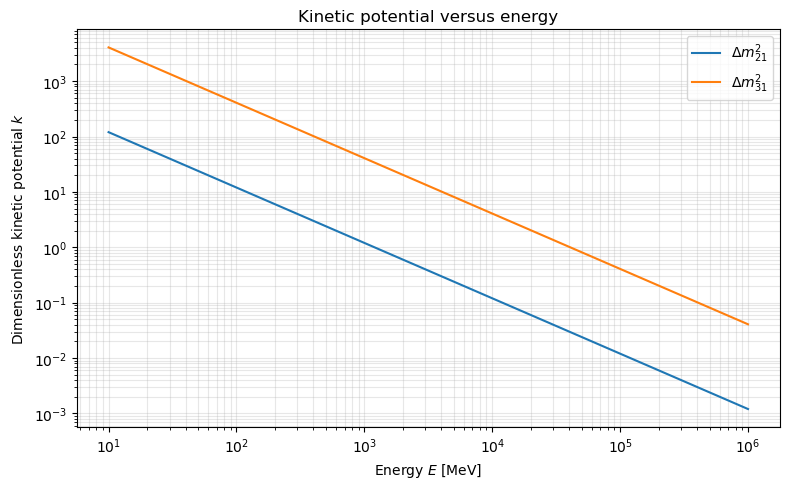

In [13]:
run_notebook_test(TEST_MODULE.plot_kinetic_potential_vs_energy)


### Plot: `plot_ratio_matter_to_kinetic`

**What is checked:** this diagnostic visualizes the numerical relationship exercised by the potential tests and makes trend regressions easy to inspect by eye.

**Expected result:** the function writes the following image file(s) to `OUTPUT_DIR` and displays the plot inline when `SHOW_PLOTS = True`:

- `matter_to_kinetic_ratio.png`

**Possible problems:** a missing file can indicate a path or permission problem; a blank, discontinuous, or non-finite curve can indicate a numerical regression or a changed tensor/device configuration.


Running plot_ratio_matter_to_kinetic ...

------------------------------------------------------------------------------------------
PLOT: matter-to-kinetic scale comparison
------------------------------------------------------------------------------------------
Saved plot: V:\output\test\core\test0_potential\plot_ratio_matter_to_kinetic_figure_001.png
------------------------------------------------------------------------------------------
PASSED: plot_ratio_matter_to_kinetic


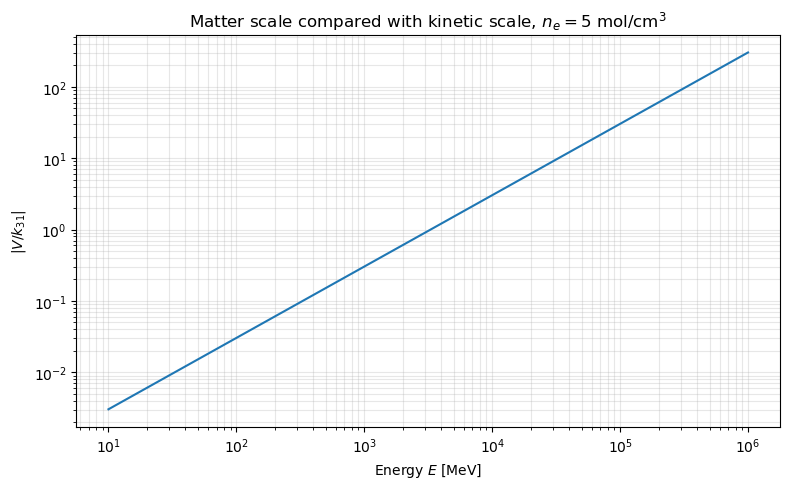

In [14]:
run_notebook_test(TEST_MODULE.plot_ratio_matter_to_kinetic)
